# Import data from UCI Machine Learning Repository
### Dataset: Online Retail
https://archive.ics.uci.edu/dataset/352/online+retail

In [84]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [85]:
from ucimlrepo import fetch_ucirepo 
import duckdb
  
# fetch dataset 
online_retail = fetch_ucirepo(id=352) 
  
# data (as pandas dataframes) 
df = online_retail.data.original 

In [86]:
df.shape

(541909, 8)

# Data Cleaning
Using SQL to clean data to demonstrate capability

In [87]:
# Filtering dataset
df = duckdb.sql(
    """
    WITH main_unfiltered AS(
        SELECT
            Description                                                                             AS description,
            Quantity                                                                                AS quantity,
            CAST(STRPTIME(InvoiceDate, '%m/%d/%Y %H:%M') AS DATE)                                   AS invoice_date,
            UnitPrice                                                                               AS unit_price,
            CAST(CustomerID AS STRING)                                                              AS customer_id,
            Country                                                                                 AS country,
            InvoiceNo                                                                               AS invoice_number,
            MAX(CAST(STRPTIME(InvoiceDate, '%m/%d/%Y %H:%M') AS DATE)) OVER ()                      AS global_max_date
        FROM
            df
    ),

    main AS (
        SELECT
            *
        FROM
            main_unfiltered
        WHERE
            invoice_date < DATE_ADD(global_max_date, INTERVAL '-3 MONTH') -- Filter out the last 90 days, this will be used for target variables
            AND description = UPPER(description) -- Filtering to just Products, Products are capitalised and adjustments such as discounts are lowercase
    ),

    max_invoice_date AS (
        SELECT
            MAX(invoice_date) AS max_date
        FROM 
            main
    ),

    customer_lifespan AS (
        SELECT
            customer_id,
            DATEDIFF('day', MIN(invoice_date), MAX(invoice_date)) AS customer_lifespan_days,
            COUNT(DISTINCT invoice_number) AS life_time_orders,
            SUM(quantity*unit_price) AS total_spend, 
            MAX(invoice_date) AS last_order_date 
        FROM
            main
        WHERE
            customer_id IS NOT NULL
        GROUP BY
            customer_id
    ),

    discount AS (
        SELECT
            customer_id,
            invoice_date,
            SUM(quantity*unit_price) AS discount,
            COUNT(invoice_number) AS number_of_discounts 
        FROM
            main_unfiltered
        WHERE
            description = 'Discount'
            AND invoice_date < DATE_ADD(global_max_date, INTERVAL '-3 MONTH')
        GROUP BY
            customer_id, 
            invoice_date
    ),

    returns AS (
        SELECT
            customer_id,
            SUM(quantity) *-1                   AS units_returned,
            SUM(quantity*unit_price) *-1        AS total_returns_value,
            COUNT(Distinct invoice_date)        AS number_of_orders_returned
        FROM
            main
        WHERE
            quantity < 0 -- Negative quantities are returned orders
        GROUP BY
            customer_id

    ),

    target_variable AS (
        SELECT DISTINCT
            customer_id,
            0 as customer_churned
        FROM 
            main_unfiltered
        WHERE
            invoice_date >= DATE_ADD(global_max_date, INTERVAL '-3 MONTH') -- Filter to the last 90 days of data
    ),
    
    final AS (
        SELECT 
            a.customer_id,
            SUM(a.quantity * a.unit_price)                                              AS total_spend,
            MAX(b.customer_lifespan_days)                                               AS customer_age_days,
            MAX(b.life_time_orders)                                                     AS total_orders,
            SUM(a.quantity * a.unit_price) / MAX(b.life_time_orders)                    AS average_order_value,
            MAX(b.customer_lifespan_days) / (MAX(b.life_time_orders) -1)                AS order_frequency,
            SUM(IFNULL(c.discount * -1, 0))                                             AS total_discount_value,
            MAX(IFNULL(c.number_of_discounts, 0))                                       AS orders_with_discounts,
            DATEDIFF('day', MAX(a.invoice_date), MAX(e.max_date))                       AS days_since_last_order,
            MAX(IFNULL(f.units_returned ,0))                                            AS units_returned,
            MAX(IFNULL(f.total_returns_value ,0))                                       AS total_returns_value,
            MAX(IFNULL(f.number_of_orders_returned ,0))                                 AS number_of_orders_returned,
            IFNULL(MAX(f.number_of_orders_returned) ,0) / MAX(b.life_time_orders)       AS orders_returned_ratio,
            MAX(IFNULL(d.customer_churned, 1))                                          AS customer_churned
        FROM 
            main a
        LEFT JOIN
            customer_lifespan b USING (customer_id)
        LEFT JOIN
            discount c USING (customer_id) -- Can sum create the count of discounts per customer then get the sum for total discount and avg discount
        LEFT JOIN
            target_variable d USING (customer_id)
        CROSS JOIN 
            max_invoice_date e
        LEFT JOIN
            returns f USING (customer_id)
        GROUP BY
            customer_id
    )

    SELECT * FROM final
    """
).df()

df

,customer_id,total_spend,customer_age_days,total_orders,average_order_value,order_frequency,total_discount_value,orders_with_discounts,days_since_last_order,units_returned,total_returns_value,number_of_orders_returned,orders_returned_ratio,customer_churned
0,12600.0,1918.56,259,9,213.173333,32.375000,0.0,0,20,1.0,18.0,1,0.111111,0
1,16554.0,221.01,127,5,44.202000,31.750000,0.0,0,112,28.0,93.1,3,0.600000,0
2,15271.0,1596.62,271,10,159.662000,30.111111,0.0,0,2,0.0,0.0,0,0.000000,0
3,18168.0,1135.74,196,9,126.193333,24.500000,0.0,0,84,8.0,34.2,3,0.333333,1
4,13151.0,1240.22,92,2,620.110000,92.000000,0.0,0,111,2.0,7.5,1,0.500000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3389,12644.0,477.91,0,1,477.910000,NaN,0.0,0,37,0.0,0.0,0,0.000000,1
3390,14536.0,171.80,0,1,171.800000,NaN,0.0,0,167,0.0,0.0,0,0.000000,1
3391,16247.0,114.56,0,1,114.560000,NaN,0.0,0,78,0.0,0.0,0,0.000000,1
3392,14647.0,243.22,0,1,243.220000,NaN,0.0,0,109,0.0,0.0,0,0.000000,1


# Logistic Regression
Visualising the input variables

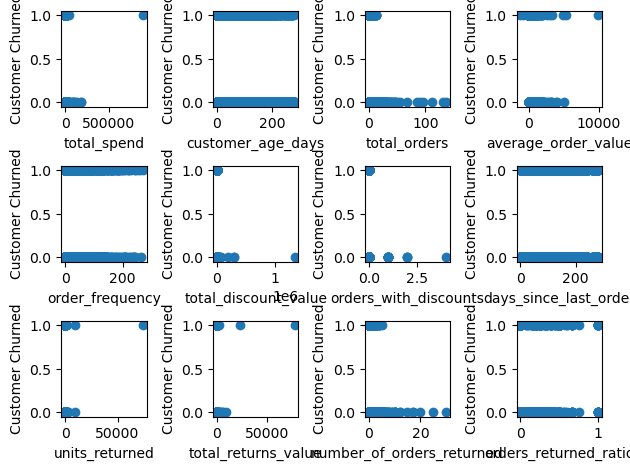

In [108]:
# Split data into train and test
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

features = ['total_spend', 'customer_age_days', 'total_orders',
            'average_order_value', 'order_frequency', 'total_discount_value',
            'orders_with_discounts', 'days_since_last_order', 'units_returned',
            'total_returns_value', 'number_of_orders_returned', 'orders_returned_ratio']

df[features] = df[features].fillna(0)

# Convert dataframe into Numpy array
X = df[features].to_numpy()
y = df['customer_churned'].to_numpy()

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, shuffle=True)

m,n = X_train.shape

figure, axes = plt.subplots(3, 4)
axes = axes.flatten()

for i in range(n):
    axes[i].scatter(X_train[:,i], y_train)
    axes[i].set_xlabel(features[i])
    axes[i].set_ylabel('Customer Churned')

plt.tight_layout()
plt.show()

### Investigate outliers